# 04. G-CTGAN Replication
**GA-Optimized G-CTGAN: An Automated Oversampling Framework for Imbalanced Data Classification**

This notebook replicates the **G-CTGAN** method proposed in the base paper
(Yang, 2026, JKIICE Vol.29 No.1) across all 11 benchmark datasets.

**G-CTGAN Pipeline:**
1. Separate minority / majority class
2. Apply GMM clustering to minority class (optimal k via BIC, search k=2..10)
3. Apply CTGAN independently to each cluster
4. Merge synthetic data with original training data

Results are saved to `results/04_gctgan_results.csv`.


## 0. Setup

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────
DATASET_DIR = "./datasets"
RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Experiment scope ───────────────────────────────────────────────────
DATASET_NAMES = [
    "credit_default",
    "fraud_detection",
    "pima_diabetes",
    "ibm_attrition",
    "yeast_me2",
    "mammography",
    "abalone_19",
    "wine_quality",
    "ecoli",
    "pageblocks",
    "protein_homo",
]

CLASSIFIERS   = ["RF", "LGBM", "MLP"]
UNIFIED_RATIO = 0.50

print(f"Datasets    : {len(DATASET_NAMES)}")
print(f"Classifiers : {CLASSIFIERS}")
print(f"Unified minority ratio: {UNIFIED_RATIO}")


Datasets    : 11
Classifiers : ['RF', 'LGBM', 'MLP']
Unified minority ratio: 0.5


## 1. Classifier & Evaluation

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from lightgbm import LGBMClassifier

def get_classifier(name, random_state=RANDOM_STATE):
    if name == "RF":
        return RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=3,
            class_weight="balanced", random_state=random_state, n_jobs=-1,
        )
    elif name == "LGBM":
        return LGBMClassifier(
            n_estimators=100, learning_rate=0.05, num_leaves=31,
            class_weight="balanced", random_state=random_state, n_jobs=-1, verbose=-1,
        )
    elif name == "MLP":
        return MLPClassifier(
            hidden_layer_sizes=(128, 64), alpha=0.001,
            max_iter=300, random_state=random_state,
        )

def evaluate(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    return {
        "AUC"      : round(roc_auc_score(y_test, y_prob), 4),
        "F1"       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred, zero_division=0), 4),
    }

print("Classifier and evaluation functions ready.")


Classifier and evaluation functions ready.


## 2. G-CTGAN Implementation

In [3]:
from sklearn.mixture import GaussianMixture
from ctgan import CTGAN

def compute_n_samples(y_train, target_ratio=UNIFIED_RATIO):
    """Compute number of synthetic minority samples to reach target_ratio."""
    n_minority = int((y_train == 1).sum())
    n_majority = int((y_train == 0).sum())
    n_target   = int(n_majority * target_ratio / (1 - target_ratio))
    return max(0, n_target - n_minority)

def select_optimal_k(X_min, k_range=range(2, 11), random_state=RANDOM_STATE):
    """
    Select optimal GMM cluster number via BIC criterion.
    Returns best k and BIC scores for all k values.
    """
    bic_scores = {}
    for k in k_range:
        if len(X_min) < k * 2:   # need at least 2 samples per cluster
            break
        try:
            gmm = GaussianMixture(
                n_components=k,
                covariance_type="full",
                random_state=random_state,
                max_iter=200,
            )
            gmm.fit(X_min)
            bic_scores[k] = gmm.bic(X_min)
        except Exception:
            continue

    if not bic_scores:
        return 2, {}

    best_k = min(bic_scores, key=bic_scores.get)
    return best_k, bic_scores

def apply_gctgan(X_train, y_train, random_state=RANDOM_STATE):
    """
    G-CTGAN oversampling (Yang, 2026):
    1. GMM clustering on minority class (BIC-optimal k)
    2. Independent CTGAN per cluster
    3. Proportional synthetic sample allocation across clusters
    """
    n_synthetic = compute_n_samples(y_train)
    if n_synthetic == 0:
        return X_train, y_train, {}

    X_min = X_train[y_train == 1].astype(float)
    X_maj = X_train[y_train == 0].astype(float)

    # ── Step 1: BIC-optimal GMM clustering ────────────────────────────
    best_k, bic_scores = select_optimal_k(X_min, random_state=random_state)

    gmm = GaussianMixture(
        n_components=best_k,
        covariance_type="full",
        random_state=random_state,
        max_iter=200,
    )
    gmm.fit(X_min)
    labels = gmm.predict(X_min)

    # ── Step 2: Proportional allocation of n_synthetic across clusters ─
    cluster_counts = np.bincount(labels, minlength=best_k)
    cluster_ratios = cluster_counts / cluster_counts.sum()
    cluster_n_syn  = np.round(cluster_ratios * n_synthetic).astype(int)

    # Adjust rounding error
    diff = n_synthetic - cluster_n_syn.sum()
    cluster_n_syn[np.argmax(cluster_counts)] += diff

    # ── Step 3: Independent CTGAN per cluster ─────────────────────────
    X_syn_list = []

    for cluster_id in range(best_k):
        n_syn_cluster = cluster_n_syn[cluster_id]
        if n_syn_cluster <= 0:
            continue

        X_cluster = X_min[labels == cluster_id]
        if len(X_cluster) < 2:
            continue

        cols     = [f"f{i}" for i in range(X_cluster.shape[1])]
        X_cl_df  = pd.DataFrame(X_cluster, columns=cols)

        try:
            model = CTGAN(epochs=100, verbose=False)
            model.fit(X_cl_df)
            X_syn_cl = model.sample(int(n_syn_cluster)).values.astype(float)
            X_syn_list.append(X_syn_cl)
        except Exception as e:
            print(f"    [Cluster {cluster_id}] CTGAN failed: {e}")
            continue

    if not X_syn_list:
        return X_train, y_train, {"best_k": best_k, "bic_scores": bic_scores}

    X_syn = np.vstack(X_syn_list)
    X_out = np.vstack([X_train.astype(float), X_syn])
    y_out = np.concatenate([y_train, np.ones(len(X_syn), dtype=int)])

    info = {
        "best_k"      : best_k,
        "bic_scores"  : bic_scores,
        "cluster_sizes": cluster_counts.tolist(),
        "cluster_n_syn": cluster_n_syn.tolist(),
    }
    return X_out, y_out, info

print("G-CTGAN implementation ready.")


G-CTGAN implementation ready.


## 3. Main Experiment Loop

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

results  = []
gmm_info = {}   # store BIC / cluster info per dataset
TOTAL    = len(DATASET_NAMES) * len(CLASSIFIERS)
done     = 0

for ds_name in DATASET_NAMES:
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    if not os.path.exists(path):
        print(f"[SKIP] {ds_name} — file not found")
        done += len(CLASSIFIERS)
        continue

    df = pd.read_csv(path)
    X  = df.drop(columns=["target"]).values.astype(float)
    y  = df["target"].values.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"\n{'='*60}")
    print(f"Dataset : {ds_name}  |  n_train={len(X_train):,}  |  minority={y_train.mean():.2%}")
    print(f"{'='*60}")

    # ── G-CTGAN oversampling ───────────────────────────────────────────
    t0 = time.time()
    try:
        X_res, y_res, info = apply_gctgan(X_train.copy(), y_train.copy())
        oversample_time = round(time.time() - t0, 2)
        ratio_res = round((y_res == 1).sum() / len(y_res), 4)
        gmm_info[ds_name] = info
        print(f"  G-CTGAN  k={info['best_k']}  n_resampled={len(y_res):,}  "
              f"minority={ratio_res:.2%}  [{oversample_time:.1f}s]")
        print(f"  Cluster sizes : {info['cluster_sizes']}")
        print(f"  Synthetic/cluster: {info['cluster_n_syn']}")
    except Exception as e:
        print(f"  G-CTGAN oversampling failed: {e}")
        done += len(CLASSIFIERS)
        continue

    # ── Train & evaluate each classifier ──────────────────────────────
    for clf_name in CLASSIFIERS:
        done += 1
        progress = f"[{done:>4}/{TOTAL}]"

        clf = get_classifier(clf_name)
        t1  = time.time()
        try:
            clf.fit(X_res, y_res)
            train_time = round(time.time() - t1, 2)
            metrics    = evaluate(clf, X_test, y_test)
        except Exception as e:
            print(f"  {progress} {ds_name} | G-CTGAN | {clf_name:<7} — Failed: {e}")
            continue

        row = {
            "dataset"          : ds_name,
            "oversampling"     : "G-CTGAN",
            "classifier"       : clf_name,
            "n_train_resampled": len(y_res),
            "minority_ratio"   : ratio_res,
            "best_k"           : info["best_k"],
            "oversample_time"  : oversample_time,
            "train_time"       : train_time,
            **metrics,
        }
        results.append(row)

        print(f"  {progress} {ds_name} | G-CTGAN | {clf_name:<7} | "
              f"AUC={metrics['AUC']:.4f}  F1={metrics['F1']:.4f}  [{train_time:.1f}s]")

print("\nExperiment complete.")



Dataset : credit_default  |  n_train=21,000  |  minority=22.12%
  G-CTGAN  k=9  n_resampled=32,710  minority=50.00%  [61.2s]
  Cluster sizes : [378, 539, 461, 1040, 335, 181, 478, 609, 624]
  Synthetic/cluster: [953, 1359, 1162, 2622, 845, 456, 1205, 1535, 1573]
  [   1/33] credit_default | G-CTGAN | RF      | AUC=0.7636  F1=0.4675  [0.8s]
  [   2/33] credit_default | G-CTGAN | LGBM    | AUC=0.7813  F1=0.4597  [0.1s]
  [   3/33] credit_default | G-CTGAN | MLP     | AUC=0.7053  F1=0.4327  [35.8s]

Dataset : fraud_detection  |  n_train=199,364  |  minority=0.17%
  G-CTGAN  k=6  n_resampled=398,040  minority=50.00%  [27.2s]
  Cluster sizes : [46, 216, 3, 4, 29, 46]
  Synthetic/cluster: [26567, 124750, 1733, 2310, 16749, 26567]
  [   4/33] fraud_detection | G-CTGAN | RF      | AUC=0.9618  F1=0.7571  [28.2s]
  [   5/33] fraud_detection | G-CTGAN | LGBM    | AUC=0.9547  F1=0.7181  [0.7s]
  [   6/33] fraud_detection | G-CTGAN | MLP     | AUC=0.9718  F1=0.8028  [45.3s]

Dataset : pima_diabete

## 4. GMM Cluster Analysis

GMM Optimal k by Dataset (BIC criterion):
Dataset              Best k       Min BIC
------------------------------------------
  credit_default            9      -48519.7
  fraud_detection           6       23196.1
  pima_diabetes             4        3080.0
  ibm_attrition             6        7251.1
  yeast_me2                 3        -173.7
  mammography               9        1337.0
  abalone_19                5        -486.2
  wine_quality              2        4114.5
  ecoli                     3        -287.6
  pageblocks                5        -295.2
  protein_homo              2      116286.7


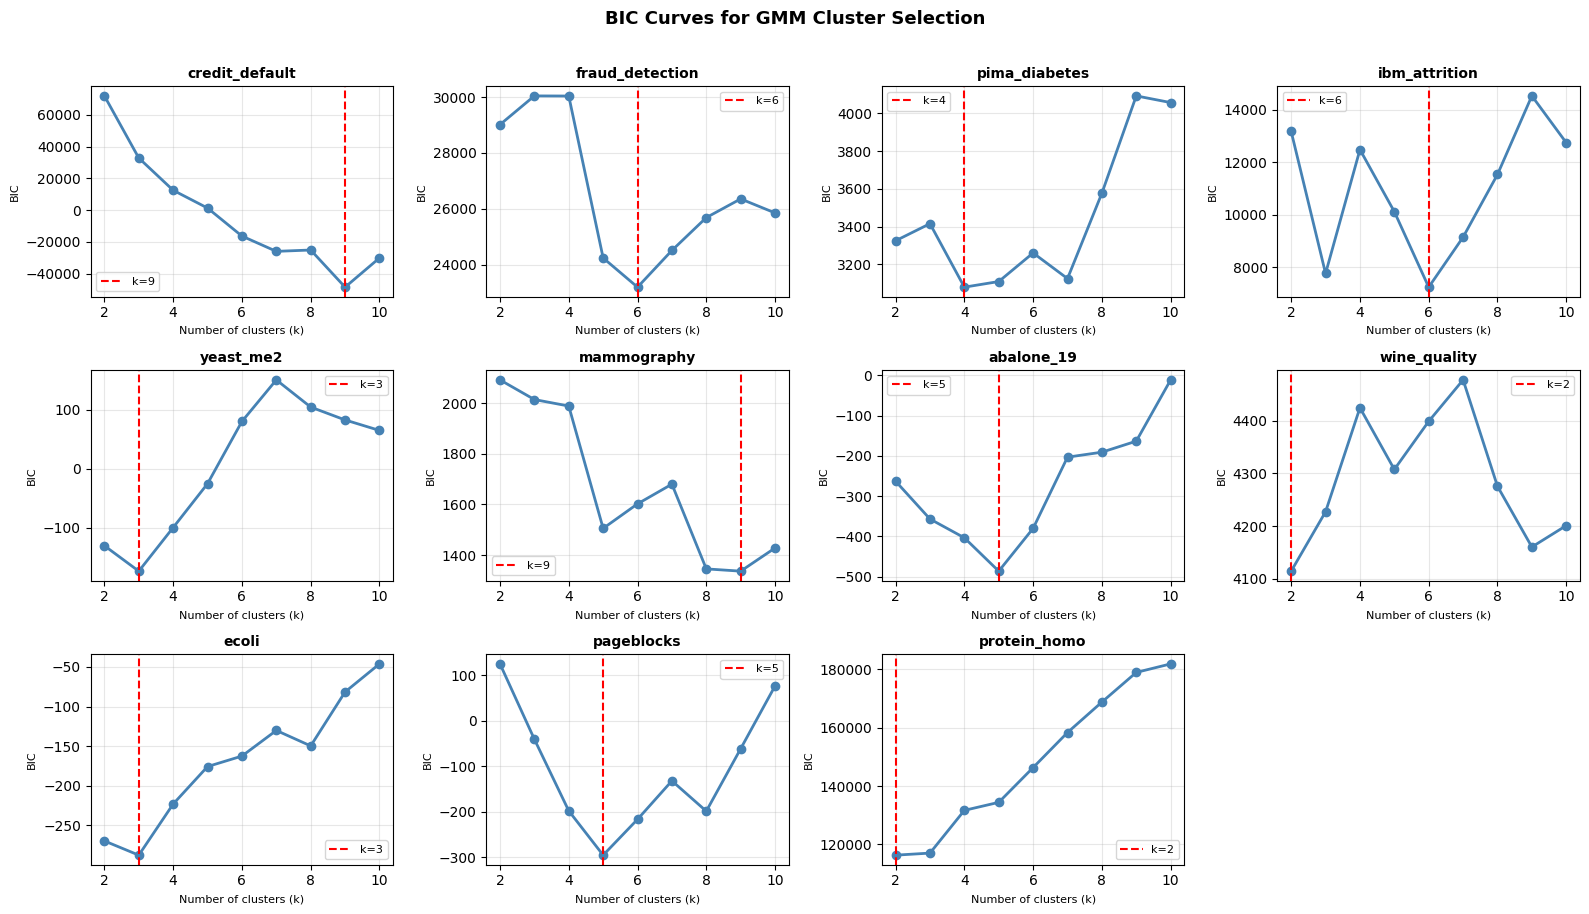

Figure saved → ./results\04_gctgan_bic_curves.png


In [5]:
import matplotlib.pyplot as plt

print("GMM Optimal k by Dataset (BIC criterion):")
print(f"{'Dataset':<20} {'Best k':>6}  {'Min BIC':>12}")
print("-" * 42)
for ds, info in gmm_info.items():
    if info:
        min_bic = min(info['bic_scores'].values()) if info['bic_scores'] else float('nan')
        print(f"  {ds:<20} {info['best_k']:>6}  {min_bic:>12.1f}")

# BIC curve plot
n_plots = len(gmm_info)
if n_plots > 0:
    ncols = min(4, n_plots)
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.array(axes).flatten() if n_plots > 1 else [axes]

    for ax, (ds, info) in zip(axes, gmm_info.items()):
        if not info or not info['bic_scores']:
            ax.set_visible(False)
            continue
        ks   = list(info['bic_scores'].keys())
        bics = list(info['bic_scores'].values())
        ax.plot(ks, bics, marker='o', color='steelblue', linewidth=2)
        ax.axvline(info['best_k'], color='red', linestyle='--',
                   linewidth=1.5, label=f"k={info['best_k']}")
        ax.set_title(ds, fontsize=10, fontweight='bold')
        ax.set_xlabel("Number of clusters (k)", fontsize=8)
        ax.set_ylabel("BIC", fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[len(gmm_info):]:
        ax.set_visible(False)

    plt.suptitle("BIC Curves for GMM Cluster Selection", fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    fig_path = os.path.join(RESULTS_DIR, "04_gctgan_bic_curves.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved → {fig_path}")


## 5. Save Results

In [6]:
results_df = pd.DataFrame(results)
save_path  = os.path.join(RESULTS_DIR, "04_gctgan_results.csv")
results_df.to_csv(save_path, index=False)
print(f"Results saved → {save_path}")
print(f"Total rows    : {len(results_df)}")
print()
print(results_df.groupby("classifier")["AUC"].mean().round(4).to_string())


Results saved → ./results\04_gctgan_results.csv
Total rows    : 33

classifier
LGBM    0.8798
MLP     0.8736
RF      0.8836


## 6. Compare with Baselines

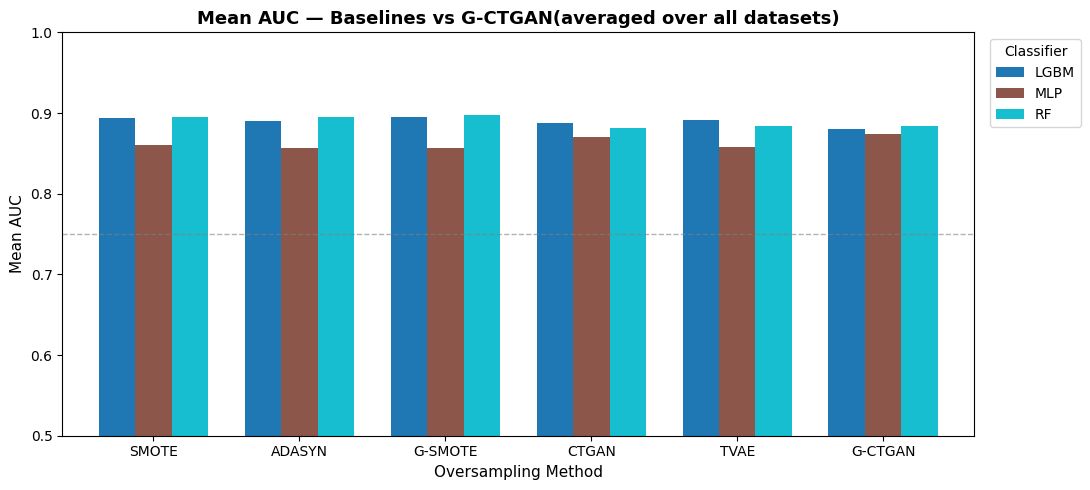

Figure saved → ./results\04_gctgan_vs_baselines.png


In [7]:
baseline_path = os.path.join(RESULTS_DIR, "02_baselines_results.csv")
if os.path.exists(baseline_path):
    baseline_df = pd.read_csv(baseline_path)
    combined_df = pd.concat([baseline_df, results_df], ignore_index=True)

    METHOD_ORDER = ["None", "SMOTE", "ADASYN", "G-SMOTE", "CTGAN", "TVAE", "G-CTGAN"]
    pivot = (combined_df
             .groupby(["oversampling", "classifier"])["AUC"]
             .mean()
             .unstack())
    pivot = pivot.reindex([m for m in METHOD_ORDER if m in pivot.index])

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot.plot(kind="bar", ax=ax, width=0.75, colormap="tab10")
    ax.set_title("Mean AUC — Baselines vs G-CTGAN(averaged over all datasets)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Oversampling Method", fontsize=11)
    ax.set_ylabel("Mean AUC", fontsize=11)
    ax.set_ylim(0.5, 1.0)
    ax.axhline(0.75, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.legend(title="Classifier", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()

    fig_path = os.path.join(RESULTS_DIR, "04_gctgan_vs_baselines.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved → {fig_path}")
else:
    print("Baseline results not found. Run 02_baselines.ipynb first.")
